In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [9]:
df = pd.read_csv("loan_approval_data.csv")

In [49]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

Handle missing values

In [22]:
categorical_cols = df.select_dtypes(include="object").columns
numerical_cols = df.select_dtypes(include=["number"]).columns

In [24]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

#EDA

Text(0.5, 1.0, 'Loan approved or not?')

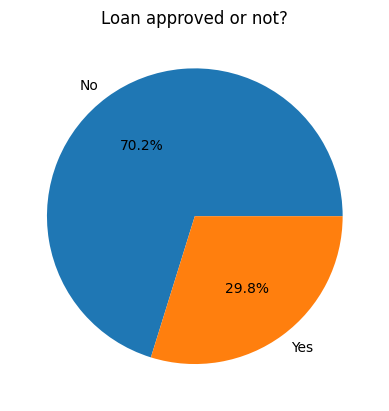

In [29]:
loan_approved_count = df["Loan_Approved"].value_counts()
plt.pie(loan_approved_count,labels=["No","Yes"],autopct="%1.1f%%")
plt.title("Loan approved or not?")

[Text(0, 0, '517'), Text(0, 0, '294'), Text(0, 0, '189')]

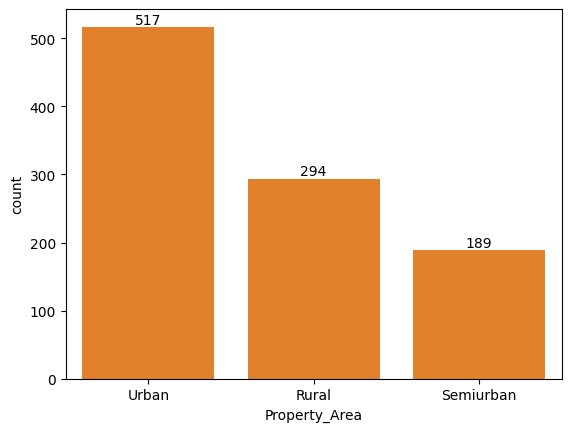

In [43]:
#categorical columns
# gender_count = df["Gender"].value_counts()
# sns.barplot(gender_count)
# ax = sns.barplot(gender_count)
# ax.bar_label(ax.containers[0])

# edu_count = df["Education_Level"].value_counts()
# sns.barplot(edu_count)
# ax = sns.barplot(edu_count)
# ax.bar_label(ax.containers[0])

prop_area_count = df["Property_Area"].value_counts()
sns.barplot(prop_area_count)
ax = sns.barplot(prop_area_count)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

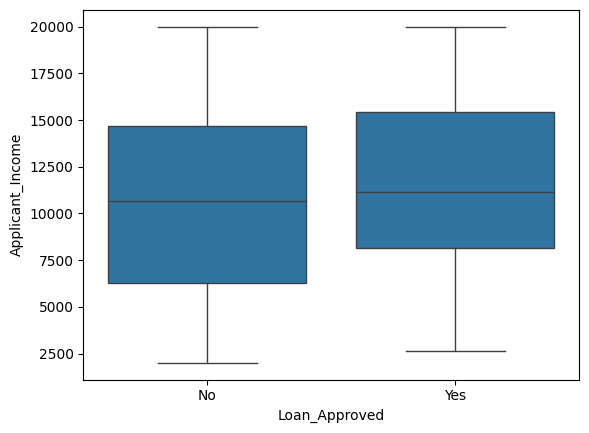

In [45]:
#Outliers-boxplot

sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)

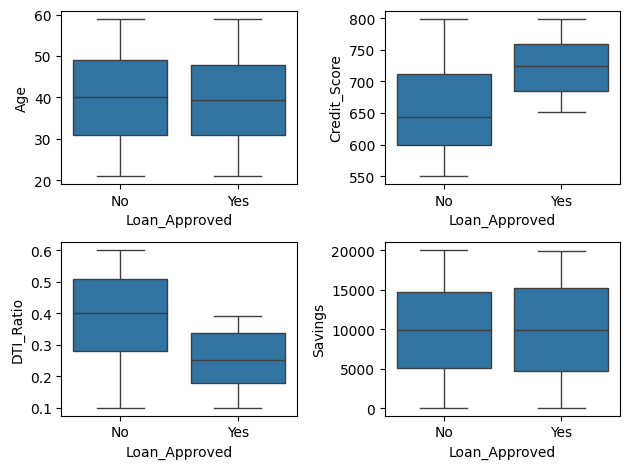

In [51]:
fig,axes = plt.subplots(2,2)
sns.boxplot(ax = axes[0,0],data=df,x="Loan_Approved",y="Age")
sns.boxplot(ax = axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax = axes[1,0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax = axes[1,1],data=df,x="Loan_Approved",y="Savings")

plt.tight_layout()

In [53]:
df = df.drop(["Applicant_ID"],axis=1)

ECODING

In [55]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [57]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [64]:
cols = ["Marital_Status","Employment_Status","Loan_Purpose","Property_Area","Employer_Category","Gender"]
ohe = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)
df = pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [66]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

CORELATION HEATMAP

In [67]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

In [ ]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

<Axes: >

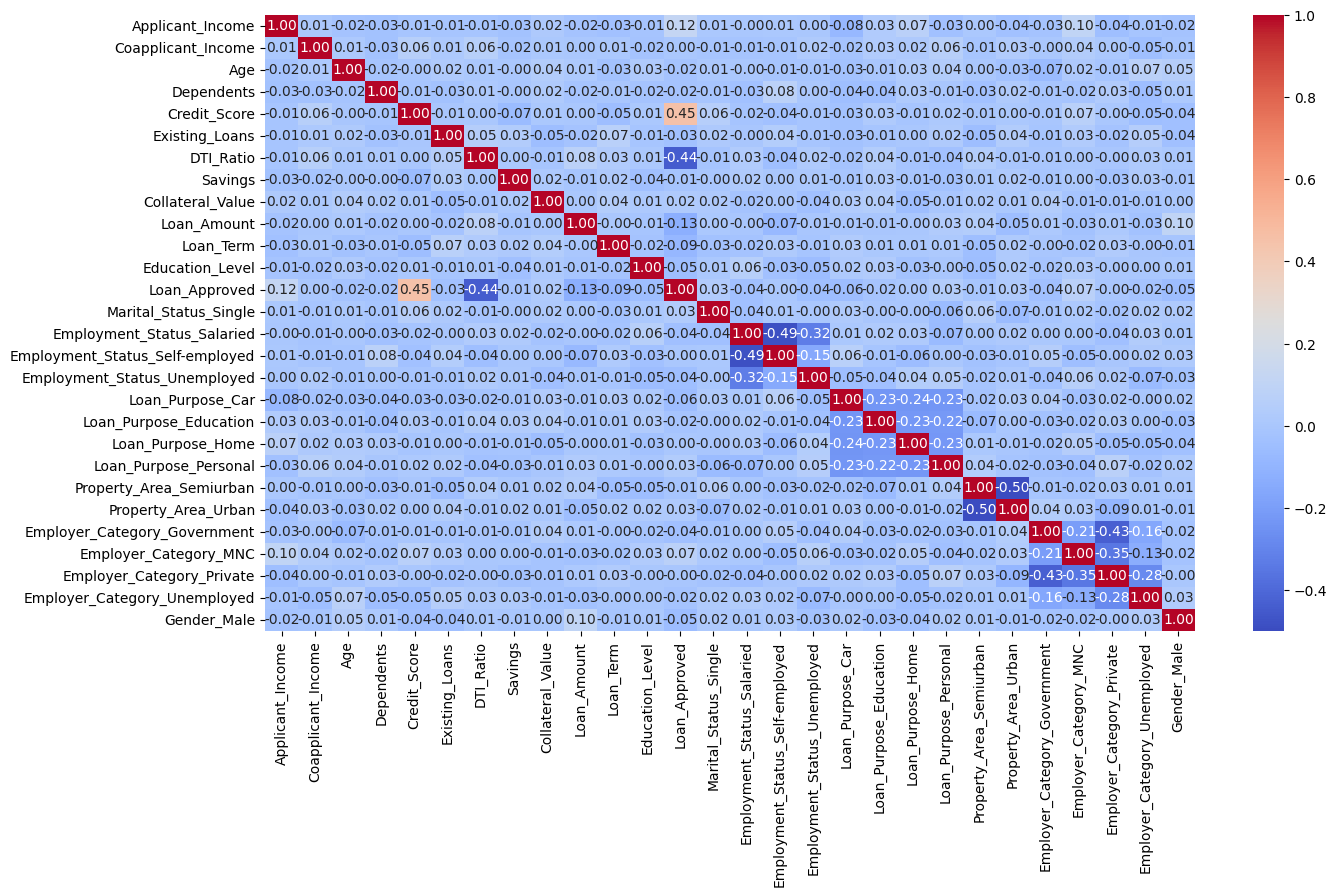

In [71]:
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

Train test split and Feature scaling

In [72]:
X = df.drop(["Loan_Approved"],axis=1)
y = df["Loan_Approved"]

In [74]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [78]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

TRAIN AND EVALUATE MODEL

In [90]:
#Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,f1_score,precision_score
lr = LogisticRegression()
lr.fit(X_train_scaled,y_train)

y_pred = lr.predict(X_test_scaled)

#Evaluation
print("Precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("f1: ",f1_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("CM: ",confusion_matrix(y_test,y_pred))

Precision:  0.7833333333333333
recall:  0.7704918032786885
f1:  0.7768595041322314
accuracy:  0.865
CM:  [[126  13]
 [ 14  47]]


In [92]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,f1_score,precision_score
KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(X_train_scaled,y_train)

y_pred = KNN.predict(X_test_scaled)

#Evaluation
print("Precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("f1: ",f1_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("CM: ",confusion_matrix(y_test,y_pred))

Precision:  0.6274509803921569
recall:  0.5245901639344263
f1:  0.5714285714285714
accuracy:  0.76
CM:  [[120  19]
 [ 29  32]]


In [93]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,f1_score,precision_score
nb = GaussianNB()
nb.fit(X_train_scaled,y_train)

y_pred = nb.predict(X_test_scaled)

#Evaluation
print("Precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("f1: ",f1_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("CM: ",confusion_matrix(y_test,y_pred))

Precision:  0.8035714285714286
recall:  0.7377049180327869
f1:  0.7692307692307693
accuracy:  0.865
CM:  [[128  11]
 [ 16  45]]


Feature engineering

In [99]:
#addn or transform features
df["DTI_Ratio_sq"] = df["DTI_Ratio"]**2
df["Credit_Score_sq"] = df["Credit_Score"]**2

#df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(["DTI_Ratio","Credit_Score","Loan_Approved"],axis=1)
y = df["Loan_Approved"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
#scaling
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [100]:
#Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,f1_score,precision_score
lr = LogisticRegression()
lr.fit(X_train_scaled,y_train)

y_pred = lr.predict(X_test_scaled)

#Evaluation
print("Precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("f1: ",f1_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("CM: ",confusion_matrix(y_test,y_pred))

Precision:  0.7846153846153846
recall:  0.8360655737704918
f1:  0.8095238095238095
accuracy:  0.88
CM:  [[125  14]
 [ 10  51]]


In [101]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,f1_score,precision_score
KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(X_train_scaled,y_train)

y_pred = KNN.predict(X_test_scaled)

#Evaluation
print("Precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("f1: ",f1_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("CM: ",confusion_matrix(y_test,y_pred))

Precision:  0.6730769230769231
recall:  0.5737704918032787
f1:  0.6194690265486725
accuracy:  0.785
CM:  [[122  17]
 [ 26  35]]


In [102]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,f1_score,precision_score
nb = GaussianNB()
nb.fit(X_train_scaled,y_train)

y_pred = nb.predict(X_test_scaled)

#Evaluation
print("Precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("f1: ",f1_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("CM: ",confusion_matrix(y_test,y_pred))

Precision:  0.8113207547169812
recall:  0.7049180327868853
f1:  0.7543859649122807
accuracy:  0.86
CM:  [[129  10]
 [ 18  43]]
